In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np



#data = xr.open_dataset('air.mon.1981-2010.ltm.nc') #para leer la media a largo plazo, 0.995 sigma (?)
data = xr.open_dataset('air.2m.mon.mean.nc') #para leer la media de cada mes a 2m de altura
#data = xr.open_dataset('air.2m.4Xday.ltm.1991-2020.nc') #para leer x4 day a 2m altura de media a largo plazo

#print(data)

temperatura = data['air']
#print(temperatura)
print(temperatura.time.size)
#print(temperatura.time.values) #muestra los valores de la lista level que se encuentra dentro del xarray temperatura




937


## Representación gráfica

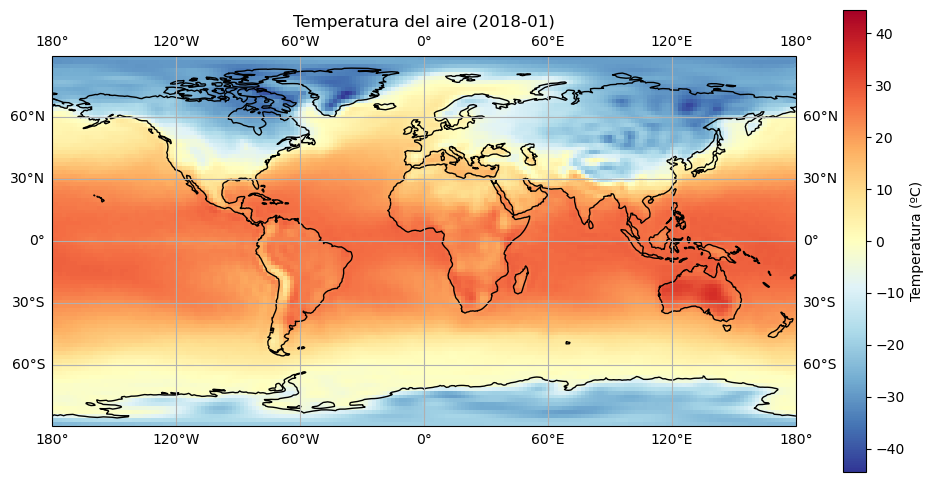

(937,)

In [2]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

year_selected = 2018
month_selected = 1
date_selected = f'{year_selected}-{month_selected:02d}'

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=0))

temperatura_celsius = temperatura - 273.15

im = temperatura_celsius.sel(time=date_selected).plot( #como estamos especificando la fecha, hay que usar .sel() en vez de .isel()
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap='RdYlBu_r',
    add_colorbar=True,
    cbar_kwargs={'label': 'Temperatura (ºC)'}
)

ax.coastlines(resolution='110m', color='black', linewidth=1.0)
#ax.add_feature(cfeature.BORDERS, linestyle=':') #muestra las fronteras de los paises
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False) #muestra la cuadrícula de coordenadas

plt.title(f'Temperatura del aire ({date_selected})')
plt.show()

#temperatura.isel(time=0).plot() #.isel() me permite seleccionar los elementos de temperatura por posición
                                         #si quisiera buscar 10 mbar de presion, por ejemplo, el codigo seria igual pero usando .sel()
#plt.show()

np.shape(temperatura['time'])



## Global Mean Surface Air Temperature


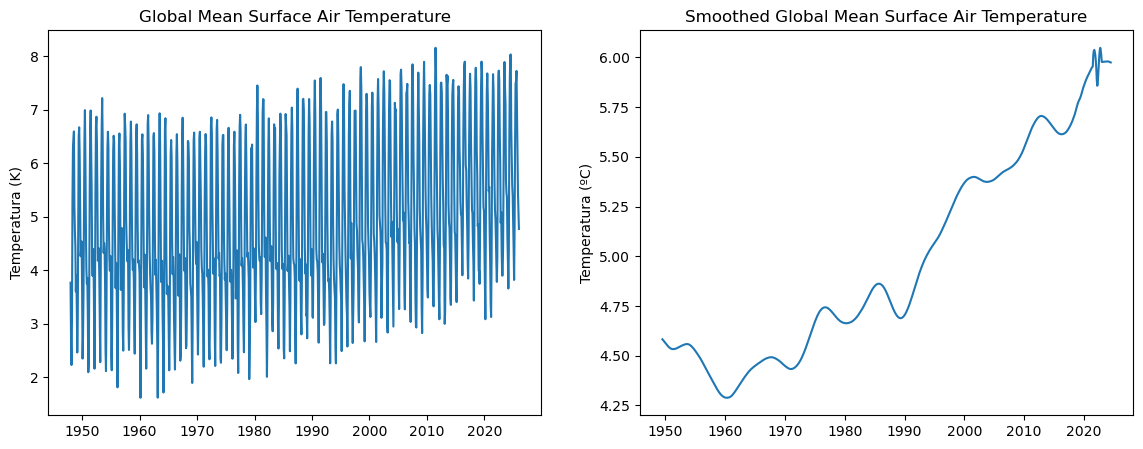

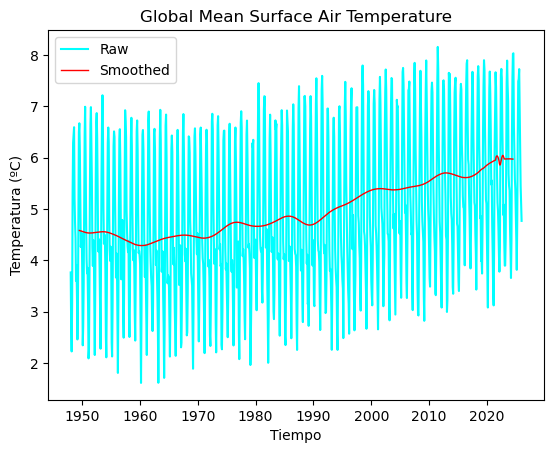

In [3]:
#quiero representar la media de temperatura de todo el globo terráqueo de cada mes a lo largo de los años 

year_selected = 2001
month_selected = 1
date_selected = f'{year_selected}-{month_selected:02d}'

global_mean_temp = temperatura_celsius.mean(dim=['lat', 'lon'])
#print(global_mean_temp)

fig, ax = plt.subplots(1, 2, figsize=(14, 5)) #un marco fig que contiene dos gráficas ax

ax[0].set_title('Global Mean Surface Air Temperature')
ax[0].set_ylabel('Temperatura (K)')
temp_plot = ax[0].plot(global_mean_temp.time, global_mean_temp)

#slow window moving average

#para empezar, hago el programa para step_size de 1, pero luego igual estaría bien generalizarlo

n_smooth = 3 #numero de veces que se suaviza la gráfica
step_size = 1 #intervalo de tiempo que se mueve la ventana, ha de ser siempre menor que la longitud de la ventana
window = 36 #longitud de la ventana

aux = global_mean_temp

def smooth_data(aux, n_smooth, step_size, window):

    """
        esta funcion suaviza una serie lineal de datos usando el metodo de 'sliding window moving average'

        n_smooth: numero de veces que hacemos el recorrido de suavizado
        step_size: distancia que se mueve la ventana en el eje x
        window: anchura de la ventana de promediados

        POR EL MOMENTO, ESTA FUNCION SOLO FUNCIONA CORRECTAMENTE PARA step_size = 1
        ADEMAS, NO MODIFICA LOS PRIMEROS NI ULTIMOS PUNTOS

    """

    for i in range(n_smooth):

        smoothed = np.zeros(aux.size)
        win_val = np.zeros(window)
        win_center = 0
        inicio = 0
        final = 0
        count = 0

        while (win_center < aux.size):
            if win_center < int(window/2):
                smoothed[win_center] = aux[win_center]

            if win_center > aux.size - 1 - int(window/2):
                smoothed[win_center] = aux[win_center]
        
            else:
                inicio = count
                final = count + window + 1
                #print(final)
                #print(np.mean(aux[inicio:final]).item())
                smoothed[win_center] = np.mean(aux[inicio:final]).item()
                #print(win_center)
            count = count + step_size
            win_center = win_center + step_size
        #print(smoothed)
        aux = smoothed

    return aux

smoothed = smooth_data(aux, n_smooth, step_size, window)

ax[1].set_title('Smoothed Global Mean Surface Air Temperature')
ax[1].set_ylabel('Temperatura (ºC)')

#temp_plot = ax[1].plot(global_mean_temp.time, smoothed)
temp_plot = ax[1].plot(global_mean_temp.time[int(window/2):937-int(window/2)], smoothed[int(window/2):937-int(window/2)]) #en la representación grafica elimino los puntos que no han sido promediados por la funcion

plt.show()

plt.plot(global_mean_temp.time, global_mean_temp, label='Raw', color='cyan')
plt.plot(global_mean_temp.time[int(window/2):937-int(window/2)], smoothed[int(window/2):937-int(window/2)], label='Smoothed', color='red', linewidth = '1')

plt.title('Global Mean Surface Air Temperature')
plt.xlabel('Tiempo')
plt.ylabel('Temperatura (ºC)')

plt.legend()

plt.show() #estaria bien pensar en alguna forma de representar este tipo de graficas usando simplemente una funcion

## Estandarización de datos y cálculo de anomalías

('time', 'lat', 'lon')


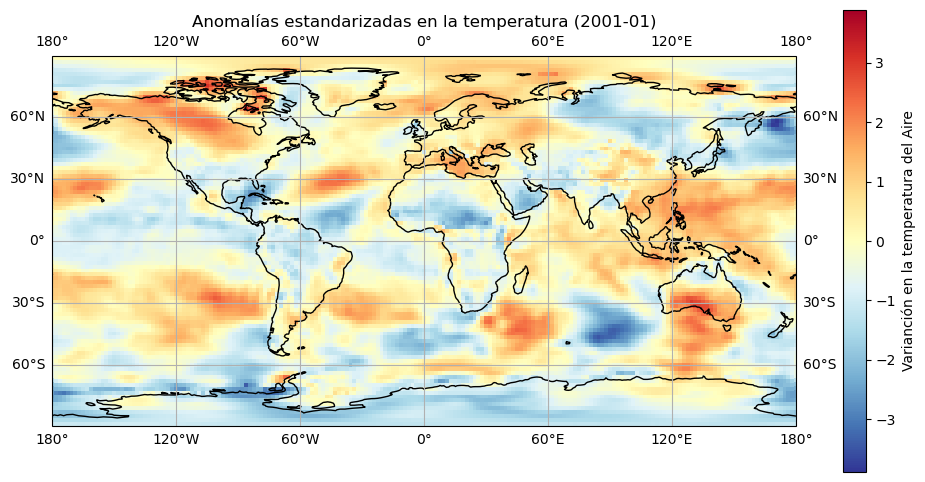

In [4]:
# Standardize Data
climatology = temperatura.groupby('time.month').mean('time') #.groupby() segmenta los datos agrupandolos por meses, de tal forma que la media se aplica de forma independiente a cada uno de dichos segmentos
std_dev = temperatura.groupby('time.month').std('time')
anomalies = (temperatura.groupby('time.month') - climatology) / std_dev #.groupby() hace la misma segmentación de climatology y std_dev, por lo que la operación es muy sencilla

# .groupby() genera una nueva dimension (month) en el DataArray, el siguiente condicional (generado por Gemini) elimina dicha dimension, quedandonos de nuevo con ('time', 'lat', 'lon')

if 'month' in anomalies.dims:
    # Seleccionamos el primer elemento de 'month' y lo eliminamos
    anomalies = anomalies.isel(month=0).drop_vars('month')
elif 'month' in anomalies.coords:
    # Si solo es una coordenada, la borramos así
    anomalies = anomalies.drop_vars('month')

year_selected = 2001
month_selected = 1
date_selected = f'{year_selected}-{month_selected:02d}'

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=0))

print(anomalies.dims)
im = anomalies.sel(time=date_selected).plot( 
    ax=ax, 
    transform=ccrs.PlateCarree(),
    cmap='RdYlBu_r',
    add_colorbar=True,
    cbar_kwargs={'label': 'Varianción en la temperatura del Aire'}
)

ax.coastlines(resolution='110m', color='black', linewidth=1.0)
#ax.add_feature(cfeature.BORDERS, linestyle=':') #muestra las fronteras de los paises
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False) #muestra la cuadrícula de coordenadas

plt.title(f'Anomalías estandarizadas en la temperatura ({date_selected})')
plt.show()

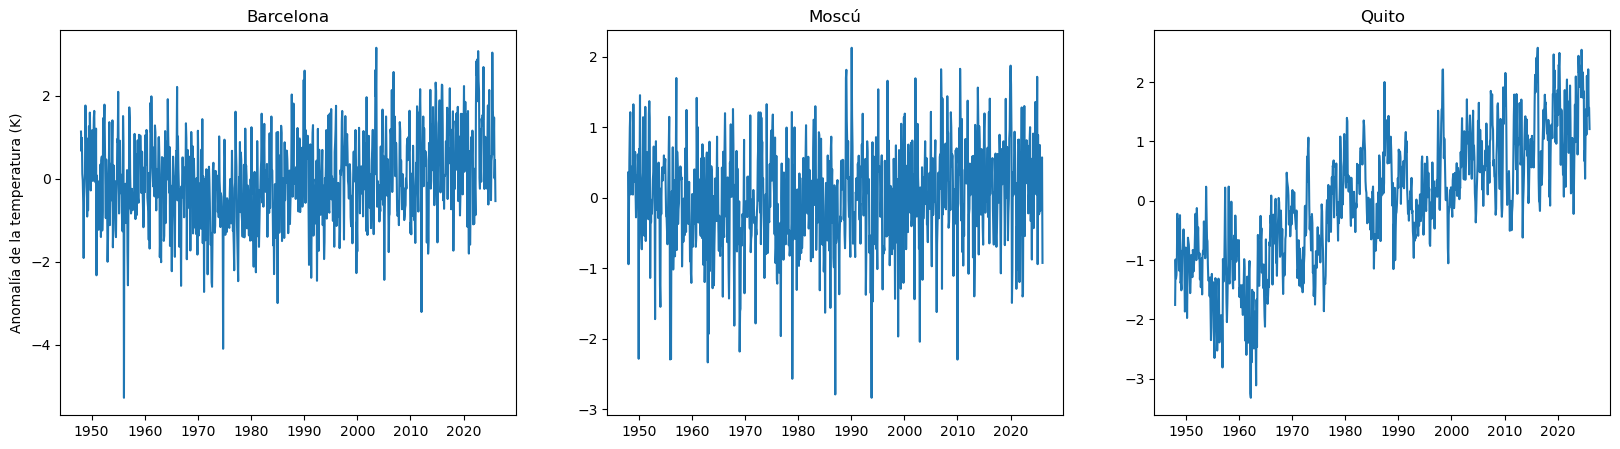

In [5]:
#el siguiente paso es ver como varian las anomalias en Barcelona, Moscu y Quito

barcelona = anomalies.sel(lat = 41.38, lon = 2.17, method='nearest')
moscu = anomalies.sel(lat = 55.75, lon = 37.60, method = 'nearest')
quito = anomalies.sel(lat = 0.2, lon = 78.5, method = 'nearest')

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

ax[0].set_title('Barcelona')
ax[0].set_ylabel('Anomalía de la temperatura (K)')
barcelona_plot = ax[0].plot(barcelona.time, barcelona)

ax[1].set_title('Moscú')
moscu_plot = ax[1].plot(moscu.time, moscu)

ax[2].set_title('Quito')
quito_plot = ax[2].plot(quito.time, quito)

plt.show()

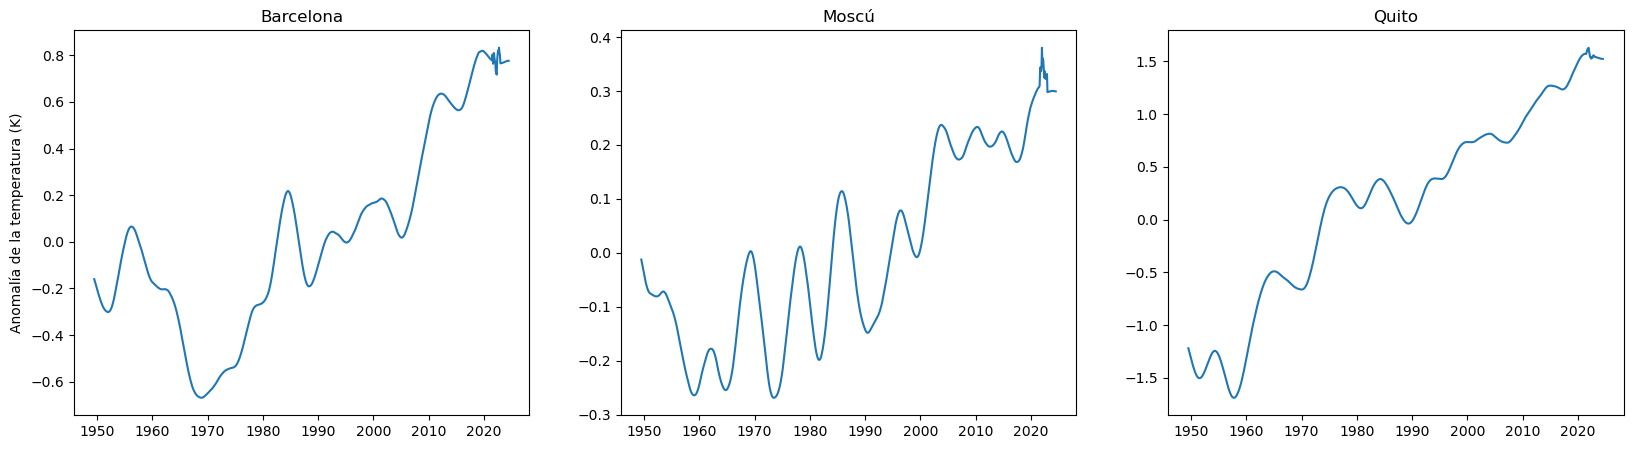

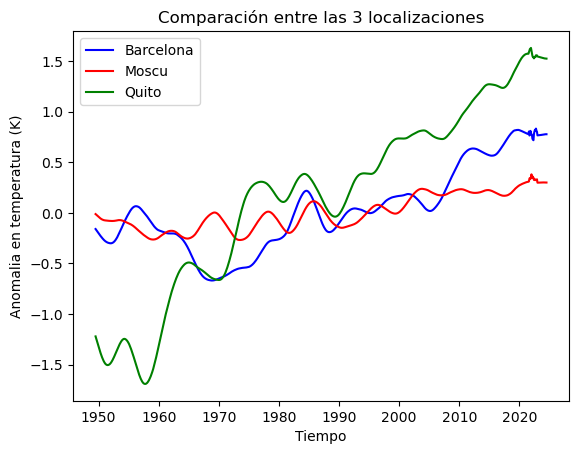

In [6]:
# veamos ahora las curvss suavizadas

smooth_barcelona = smooth_data(barcelona, n_smooth, step_size, window)
smooth_moscu = smooth_data(moscu, n_smooth, step_size, window)
smooth_quito = smooth_data(quito, n_smooth, step_size, window)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

ax[0].set_title('Barcelona')
ax[0].set_ylabel('Anomalía de la temperatura (K)')
barcelona_plot = ax[0].plot(barcelona.time[int(window/2):937-int(window/2)], smooth_barcelona[int(window/2):937-int(window/2)])

ax[1].set_title('Moscú')
moscu_plot = ax[1].plot(moscu.time[int(window/2):937-int(window/2)], smooth_moscu[int(window/2):937-int(window/2)])

ax[2].set_title('Quito')
quito_plot = ax[2].plot(quito.time[int(window/2):937-int(window/2)], smooth_quito[int(window/2):937-int(window/2)])

plt.show()

# representacion de las anomalias en la misma grafica

plt.plot(anomalies.time[int(window/2):937-int(window/2)], smooth_barcelona[int(window/2):937-int(window/2)], label='Barcelona', color='blue')
plt.plot(anomalies.time[int(window/2):937-int(window/2)], smooth_moscu[int(window/2):937-int(window/2)], label='Moscu', color='red')
plt.plot(anomalies.time[int(window/2):937-int(window/2)], smooth_quito[int(window/2):937-int(window/2)], label='Quito', color='green')

plt.title('Comparación entre las 3 localizaciones')
plt.xlabel('Tiempo')
plt.ylabel('Anomalia en temperatura (K)')

plt.legend()

plt.show()

# Implementación de redes
## Matriz de correlaciones


In [30]:
%%time
#para empezar, voy a crear matrices de correlaciones a partir de redes de 9 (3x3), 16 (4x4), 25 (5x5) nodos y medir cuanto tiempo tardan en calcularse

#puede ser interesante implementar un algoritmo que seleccione 9, 16, 25 nodos aleatorios para estandarizar el tiempo de cálculo, pero por ahora voy a cogerlos manualmente

anomalies_5x5 = anomalies.isel(lat=slice(0, 5), lon=slice(0, 5)) #cuadricula de la esquina superior izq

#necesito un bucle que recorra mi nueva red comparando nodo por nodo. por ejemplo, un doble bucle que recorra latitudes y longitudes debería servir???

#print(np.mean(anomalies_3x3).item())

def pearson_corr(ser1, ser2):

    """
        esta funcion calcula la correlacion de pearson entre dos series temporales, que deben ser introducidas en forma de xarray
        he seguido la formula 4 del paper "Complex Networks as a Unified Framework for Descriptive Analysis and Predictive Modeling in Climate" de Karsten Steinhaeuser
    
    """

    mean1 = np.mean(ser1).item() #a
    mean2 = np.mean(ser2).item() #b

    numerator = 0
    aux1 = 0
    aux2 = 0
    
    for i in range(ser1.time.size):
        numerator = numerator + ((ser1.isel(time=i) - mean1) * (ser2.isel(time=i) - mean2))
        aux1 = aux1 + (ser1.isel(time=i) - mean1)**2
        aux2 = aux2 + (ser2.isel(time=i) - mean2)**2

    denominator = np.sqrt(aux1 * aux2)

    return numerator/denominator

def corr_matrix(grid):

    n_lat = grid.lat.size
    n_lon = grid.lon.size
    n_nodes = n_lat * n_lon

    correlations = np.zeros((n_nodes, n_nodes))
    row = 0

    for i in range(n_lat): #estos dos primeros bucles recorren las filas de la matriz de correlaciones
        for j in range(n_lon):

            column = 0

            for k in range(n_lat): #este bucle recorre las latitudes de nuestra cuadricula de nodos
                for l in range(n_lon): #este bucle recorre las longitudes de nuestra cuadricula de nodos

                        """
                            es muy importante tener en cuenta el orden que estoy usando con estos pares de bucles. como el bucle de abajo es el de las longitudes,
                            el orden de nodos que estoy asignando es:
                            - el primer nodo (0) será el lat = 0, lon = 0
                            - el segundo será el lat = 0, lon = 1
                            - asi sucesivamente hasta el nodo numero n_lon - 1, que sera el lat = 1, lon = 0
                            - asi hasta acabar la cuadricula
                            es muy importante saber de qué forma estoy ordenando los nodos para poder revertirlo y calcular la matriz de adyacencia a partir de 
                            la matriz de correlaciones, que no entiende de lat y lon, sino de indices numerados (i, j)

                        """

                        correlations[row][column] = pearson_corr(grid.isel(lat=i, lon=j), grid.isel(lat=k, lon=l))
                        column = column + 1
                        
            print(row)
            row = row + 1


    return correlations

corr = corr_matrix(anomalies_5x5)
print(corr.shape)
print(corr)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
(25, 25)
[[1.         0.99995184 0.99981767 0.99958533 0.99929178 0.96907598
  0.96837443 0.96729398 0.96621692 0.96493751 0.89642209 0.89386886
  0.89127326 0.88850611 0.88568276 0.80341691 0.79729915 0.79166746
  0.78636491 0.7814936  0.678532   0.6679405  0.66080946 0.65410149
  0.64186543]
 [0.99995184 1.         0.99995315 0.99980408 0.99958962 0.96898282
  0.96843457 0.96750003 0.96657115 0.96543974 0.89645225 0.89405847
  0.89161807 0.88901275 0.8863489  0.80348867 0.79750204 0.79200053
  0.78682703 0.78208339 0.67871517 0.6682145  0.66116607 0.65453887
  0.64235783]
 [0.99981767 0.99995315 1.         0.99994534 0.99981374 0.96871275
  0.96831387 0.96752924 0.96675438 0.96577007 0.8962298  0.89399755
  0.89171326 0.88926935 0.88676614 0.80327666 0.7974304  0.79206389
  0.78703213 0.78243142 0.67868495 0.66829151 0.66134095 0.65482593
  0.64272004]
 [0.99958533 0.99980408 0.99994534 1.         0.99995285 0.96827066


In [31]:
import os

file_name = os.path.join("corr_matrices", "5x5.txt")

np.savetxt(file_name, corr, fmt='%.10f', delimiter=',') #guardo la matriz de correlaciones en un archivo de texto